In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

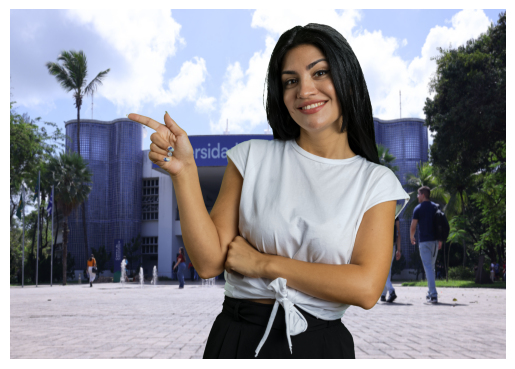

In [3]:

# 1. Carregar imagem com fundo verde e novo fundo
fg = cv2.imread("projeto_1/img_fundo_verde_1.jpg")   # pessoa/objeto com fundo verde
bg = cv2.imread("projeto_1/background_1.png")         # nova imagem de fundo

# Redimensionar fundo para o mesmo tamanho
bg = cv2.resize(bg, (fg.shape[1], fg.shape[0]))

# 2. Converter para HSV (mais fácil isolar o verde)
hsv = cv2.cvtColor(fg, cv2.COLOR_BGR2HSV)

# 3. Definir intervalo de verde (ajuste os valores conforme sua imagem)
lower_green = np.array([35, 40, 40])   # H, S, V
upper_green = np.array([85, 255, 255])

# 4. Criar máscara onde é verde
mask = cv2.inRange(hsv, lower_green, upper_green)

# 5. Inverter máscara (255 = sujeito, 0 = fundo verde)
mask_inv = cv2.bitwise_not(mask)

# 6. Isolar o objeto (remove o verde)
fg_no_green = cv2.bitwise_and(fg, fg, mask=mask_inv)

# 7. Isolar apenas a região onde era verde no background
bg_region = cv2.bitwise_and(bg, bg, mask=mask)

# 8. Combinar
final = cv2.add(fg_no_green, bg_region)
final = cv2.cvtColor(final,cv2.COLOR_BGR2RGB)

plt.imshow(final)
plt.axis("off")
plt.show()

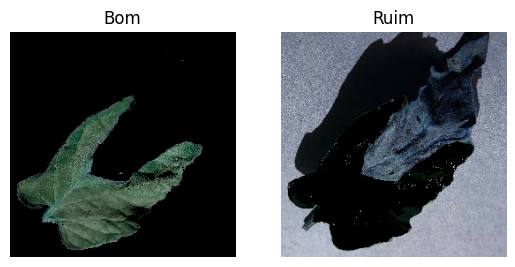

In [7]:
# 1. Carregar imagem
img = cv2.imread("projeto_2/img_folha_3.JPG")

# 2. Converter para HSV (mais robusto p/ cor)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 3. Definir faixa de cor (ex.: verde)
# Ajuste esses valores conforme sua imagem
lower = (25, 40, 40)
upper = (70, 255, 230)
# 4. Criar máscara binária
mask = cv2.inRange(hsv, lower, upper)
mask_inv = cv2.bitwise_not(mask)
# 5. Aplicar máscara na imagem original (segmento colorido)
bom = cv2.bitwise_and(img, img, mask=mask)
ruim = cv2.bitwise_and(img,img,mask=mask_inv)
plt.subplot(1,2,1)
plt.title("Bom")
plt.axis("off")
plt.imshow(bom)

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Ruim")
plt.imshow(ruim)